# Name: Prathamesh Balaji Patil
# Roll: 11
# Div: TY A(AIML)
# Experiment No. 4
# Assignment

## Logistic Regression for Binary Classification

**Dataset:** `account_.csv`

**Objective:** Predict the type of card assigned to a bank account using Logistic Regression based on the account type.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Step 1: Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc


## Step 2: Load Dataset

In [3]:
# Load the account dataset
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/account_.csv")

# Display the first five rows
df.head()


,account_id,Account_type,Card_Assigned
0,1573,Savings account,Silver
1,3276,Salary account,Silver
2,124,Salary account,Diamond
3,3958,NRI account,Silver
4,777,Savings account,Silver


## Step 3: Understand the Dataset

In [4]:
# Display the number of rows and columns
print("Dataset shape:", df.shape)

# Display column names and data types
df.info()


Dataset shape: (49, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   account_id     49 non-null     int64 
 1   Account_type   49 non-null     object
 2   Card_Assigned  49 non-null     object
dtypes: int64(1), object(2)
memory usage: 1.3+ KB


In [5]:
# Display descriptive information for the dataset
df.describe(include="all")


,account_id,Account_type,Card_Assigned
count,49.000000,49,49
unique,NaN,3,2
top,NaN,Salary account,Silver
freq,NaN,19,45
mean,2148.897959,NaN,NaN
std,1280.325972,NaN,NaN
min,124.000000,NaN,NaN
25%,906.000000,NaN,NaN
50%,2440.000000,NaN,NaN
75%,3187.000000,NaN,NaN


In [6]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())


Missing values in each column:
account_id       0
Account_type     0
Card_Assigned    0
dtype: int64


In [7]:
# Check for duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())


Number of duplicate rows: 0


## Step 4: Data Preprocessing

In [8]:
# Remove duplicate rows, if any
df = df.drop_duplicates().reset_index(drop=True)

# Check the unique values in categorical columns
print("Account types:", df["Account_type"].unique())
print("Card types:", df["Card_Assigned"].unique())


Account types: ['Savings account' 'Salary account' 'NRI account']
Card types: ['Silver' 'Diamond']


## Step 5: Exploratory Data Analysis

`account_id` is a unique identifier, so it is not used as a predictive feature.  
`Account_type` is used as the input feature and `Card_Assigned` is the binary target.

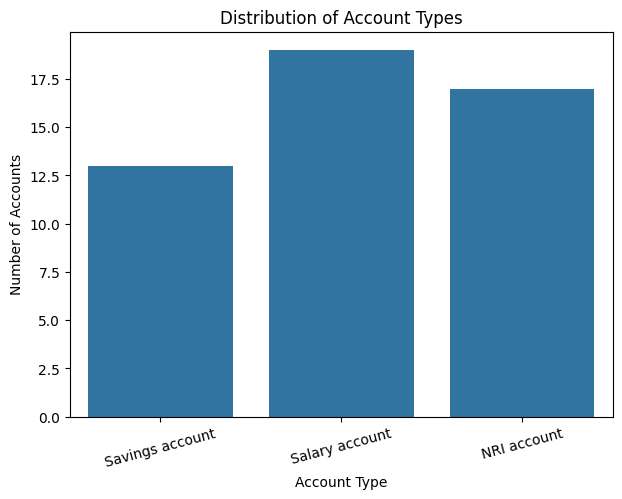

In [9]:
# Count of each account type
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Account_type")
plt.xlabel("Account Type")
plt.ylabel("Number of Accounts")
plt.title("Distribution of Account Types")
plt.xticks(rotation=15)
plt.show()


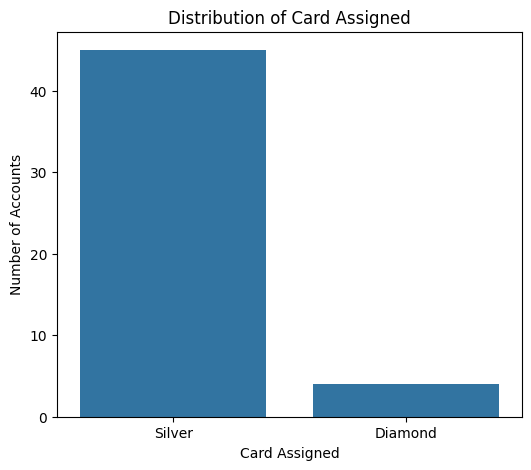

In [10]:
# Count of each assigned card type
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x="Card_Assigned")
plt.xlabel("Card Assigned")
plt.ylabel("Number of Accounts")
plt.title("Distribution of Card Assigned")
plt.show()


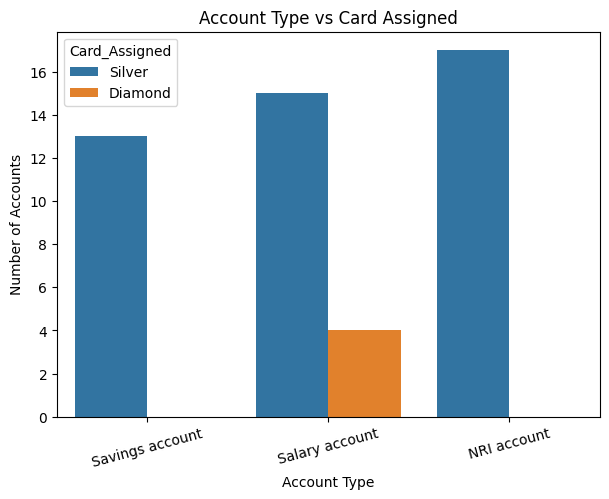

In [11]:
# Relationship between Account Type and Card Assigned
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Account_type", hue="Card_Assigned")
plt.xlabel("Account Type")
plt.ylabel("Number of Accounts")
plt.title("Account Type vs Card Assigned")
plt.xticks(rotation=15)
plt.show()


## Step 6: Feature Selection

In [12]:
# Independent variable (feature)
X = df[["Account_type"]]

# Dependent variable (target)
y = df["Card_Assigned"]

print("Features:")
display(X.head())

print("Target:")
display(y.head())


Features:


,Account_type
0,Savings account
1,Salary account
2,Salary account
3,NRI account
4,Savings account


Target:


,Card_Assigned
0,Silver
1,Silver
2,Diamond
3,Silver
4,Silver


## Step 7: Encode the Target Variable

In [13]:
# Convert target labels into numerical values
# The mapping is displayed so the prediction results are easy to interpret.
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Target classes:", label_encoder.classes_)

target_mapping = {
    label: int(label_encoder.transform([label])[0])
    for label in label_encoder.classes_
}
print("Target mapping:", target_mapping)


Target classes: ['Diamond' 'Silver']
Target mapping: {'Diamond': 0, 'Silver': 1}


## Step 8: Train-Test Split

In [14]:
# Split the dataset into 80% training data and 20% testing data.
# stratify=y_encoded keeps the class distribution as balanced as possible.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 39
Testing samples: 10


## Step 9: Encode the Categorical Feature

In [15]:
# One-hot encode Account_type because it is a categorical feature.
# handle_unknown="ignore" prevents errors for unseen account types.
preprocessor = ColumnTransformer(
    transformers=[
        ("account_type", OneHotEncoder(handle_unknown="ignore"), ["Account_type"])
    ]
)


## Step 10: Model Training

In [16]:
# Create the Logistic Regression model.
# class_weight="balanced" helps because the dataset contains many more
# Silver cards than Diamond cards.
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            class_weight="balanced",
            random_state=42,
            max_iter=1000
        ))
    ]
)

# Train the model
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")


Logistic Regression model trained successfully.


## Step 11: Predictions

In [17]:
# Predict the card assigned for the test data
y_pred = model.predict(X_test)

# Convert numerical predictions back to original labels
y_pred_labels = label_encoder.inverse_transform(y_pred)

print("Predicted Card Types:")
print(y_pred_labels)


Predicted Card Types:
['Diamond' 'Silver' 'Silver' 'Silver' 'Diamond' 'Silver' 'Silver' 'Silver'
 'Silver' 'Diamond']


## Step 12: Model Evaluation

In [18]:
# Calculate model accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", round(accuracy * 100, 2), "%")


Accuracy: 0.8
Accuracy (%): 80.0 %


Confusion Matrix:
[[1 0]
 [2 7]]


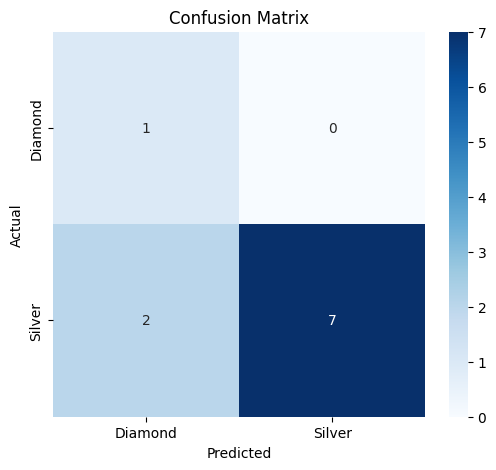

In [19]:
# Display the confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [20]:
# Display the classification report
print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)


Classification Report:
              precision    recall  f1-score   support

     Diamond       0.33      1.00      0.50         1
      Silver       1.00      0.78      0.88         9

    accuracy                           0.80        10
   macro avg       0.67      0.89      0.69        10
weighted avg       0.93      0.80      0.84        10



## Step 13: ROC Curve

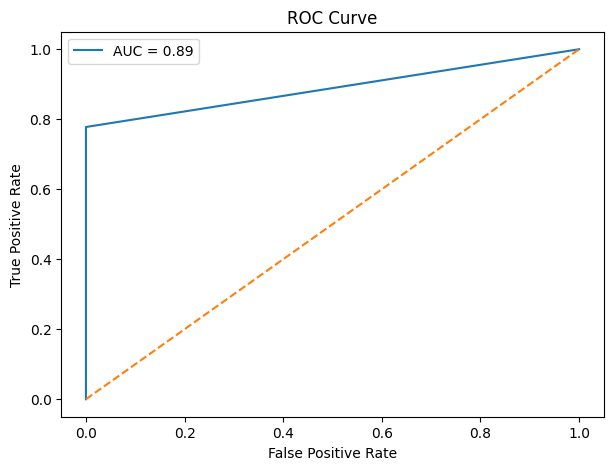

AUC: 0.89


In [21]:
# Get probability of the positive class.
# LabelEncoder sorts the classes alphabetically, so class 1 is:
# label_encoder.classes_[1]
y_prob = model.predict_proba(X_test)[:, 1]

# Calculate False Positive Rate and True Positive Rate
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate Area Under the Curve
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label="AUC = %.2f" % roc_auc)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("AUC:", round(roc_auc, 2))


## Step 14: Predict Card for a New Account

In [22]:
# Example prediction for a new account
new_account = pd.DataFrame({
    "Account_type": ["Salary account"]
})

new_prediction = model.predict(new_account)
new_prediction_label = label_encoder.inverse_transform(new_prediction)

print("Account Type:", new_account.loc[0, "Account_type"])
print("Predicted Card Assigned:", new_prediction_label[0])


Account Type: Salary account
Predicted Card Assigned: Diamond


## Step 15: Save the Trained Model

In [25]:
import pickle

# Save the complete Logistic Regression pipeline
# This includes One-Hot Encoding + Logistic Regression model
with open("logistic_regression_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("logistic_regression_model.pkl")

BCModel2.pkl


## Step 15: Conclusion

Logistic Regression was successfully applied to the given bank account dataset for binary classification of `Card_Assigned`. The categorical `Account_type` feature was converted using One-Hot Encoding, while the target variable was encoded into numerical classes. The model was trained using an 80:20 train-test split and evaluated using accuracy, confusion matrix, classification report, and ROC-AUC.

**Note:** The dataset contains only 49 records and the target classes are imbalanced, with substantially more Silver cards than Diamond cards. Therefore, accuracy alone should not be used to judge the model; the classification report and confusion matrix should also be considered.